# Bước 3 – Kỹ Thuật Đặc Trưng (Feature Engineering)

## Mục tiêu
Đây là bước **quan trọng nhất** quyết định chất lượng mô hình. Tạo các đặc trưng (features) có ý nghĩa từ dữ liệu giá thô để giúp mô hình ML phát hiện các pattern dự báo xu hướng.

## Các nhóm đặc trưng:

### 3.1. Chỉ báo kỹ thuật (Technical Indicators)
| Chỉ báo | Mô tả | Tham số |
|---------|-------|---------|
| **SMA** | Simple Moving Average | Window = 10, 20, 50 ngày |
| **EMA** | Exponential Moving Average | Span = 12, 26 ngày |
| **RSI** | Relative Strength Index | Period = 14 ngày |
| **MACD** | Moving Average Convergence Divergence | Fast=12, Slow=26, Signal=9 |
| **Bollinger Bands** | Upper/Middle/Lower Band | Window=20, Std=2 |

### 3.2. Đặc trưng trễ (Lag Features)
- Giá đóng cửa của 1, 3, 7 phiên trước đó

### 3.3. Đặc trưng biến động (Volatility Features)
- Rolling standard deviation 10 phiên gần nhất

### 3.4. Biến mục tiêu (Target Variable)
- **Phân loại**: target = 1 nếu giá ngày mai tăng, 0 nếu giảm
- **Hồi quy**: target = giá đóng cửa ngày t+1

## Lưu ý:
- Feature engineering áp dụng trên dữ liệu giá **GỐC** (chưa tính return, chưa scale)
- Áp dụng riêng cho train và test để **tránh data leakage**

## 3.1. Import thư viện và cấu hình

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cấu hình hiển thị
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

# === ĐƯỜNG DẪN ===
RAW_DATA_DIR = os.path.join('..', 'data', 'raw')
PROCESSED_DIR = os.path.join('..', 'data', 'processed')
FE_DIR = os.path.join(PROCESSED_DIR, 'feature_engineered')
os.makedirs(FE_DIR, exist_ok=True)

# Mã cổ phiếu
STOCK_SYMBOLS = ['VCB', 'FPT', 'HPG', 'VIC', 'POW']

# Mốc chia train/test (phải giống Bước 2)
SPLIT_DATE = '2025-01-01'

print(f"Thư mục dữ liệu thô: {RAW_DATA_DIR}")
print(f"Thư mục output: {FE_DIR}")
print(f"Mốc chia train/test: {SPLIT_DATE}")

Thư mục dữ liệu thô: ..\data\raw
Thư mục output: ..\data\processed\feature_engineered
Mốc chia train/test: 2025-01-01


## 3.2. Tải dữ liệu giá gốc

Feature engineering cần dữ liệu **giá gốc** (OHLCV) — không phải daily return hay scaled data — vì các chỉ báo kỹ thuật (SMA, EMA, RSI...) được tính trực tiếp trên giá.

In [2]:
# Tải dữ liệu giá gốc từ data/raw/
raw_data = {}

for symbol in STOCK_SYMBOLS:
    filepath = os.path.join(RAW_DATA_DIR, f'{symbol}.csv')
    df = pd.read_csv(filepath)
    df['time'] = pd.to_datetime(df['time'])
    df = df.sort_values('time').reset_index(drop=True)
    raw_data[symbol] = df
    print(f"✓ {symbol}: {df.shape} | {df['time'].min().date()} → {df['time'].max().date()}")

# Tải VN-Index và USD/VND cho features bổ sung
supplement_data = {}
for name in ['VNINDEX', 'USDVND']:
    filepath = os.path.join(RAW_DATA_DIR, f'{name}.csv')
    if os.path.exists(filepath):
        df = pd.read_csv(filepath)
        df['time'] = pd.to_datetime(df['time'])
        df = df.sort_values('time').reset_index(drop=True)
        supplement_data[name] = df
        print(f"✓ {name}: {df.shape}")

print(f"\n→ Đã tải {len(raw_data)} mã CP + {len(supplement_data)} dữ liệu bổ sung")

✓ VCB: (1623, 6) | 2019-09-17 → 2026-03-18
✓ FPT: (1623, 6) | 2019-09-17 → 2026-03-18
✓ HPG: (1623, 6) | 2019-09-17 → 2026-03-18
✓ VIC: (1623, 6) | 2019-09-17 → 2026-03-18
✓ POW: (1623, 6) | 2019-09-17 → 2026-03-18
✓ VNINDEX: (1623, 6)
✓ USDVND: (1615, 6)

→ Đã tải 5 mã CP + 2 dữ liệu bổ sung


## 3.3. Định nghĩa các hàm tính chỉ báo kỹ thuật

Mỗi chỉ báo kỹ thuật phản ánh một khía cạnh khác nhau của thị trường:
- **SMA/EMA**: Xu hướng (trend) — giá trung bình qua các cửa sổ thời gian khác nhau
- **RSI**: Động lượng (momentum) — mức quá mua/quá bán (>70 = overbought, <30 = oversold)
- **MACD**: Tín hiệu mua/bán — giao cắt giữa đường MACD và signal
- **Bollinger Bands**: Biến động (volatility) — giá ở ngoài band = bất thường

In [3]:
# ============================================================
# HÀM TÍNH CHỈ BÁO KỸ THUẬT (Technical Indicators)
# ============================================================

def calculate_sma(df, windows=[10, 20, 50]):
    """
    Simple Moving Average (SMA) — Trung bình giá đóng cửa qua n phiên.
    SMA_10: xu hướng ngắn hạn, SMA_50: xu hướng dài hạn.
    Khi SMA ngắn cắt lên SMA dài → tín hiệu tăng (Golden Cross).
    """
    for window in windows:
        df[f'SMA_{window}'] = df['close'].rolling(window=window).mean()
    return df

def calculate_ema(df, spans=[12, 26]):
    """
    Exponential Moving Average (EMA) — Giống SMA nhưng ưu tiên dữ liệu gần hơn.
    EMA phản ứng nhanh hơn SMA với biến động giá gần đây.
    """
    for span in spans:
        df[f'EMA_{span}'] = df['close'].ewm(span=span, adjust=False).mean()
    return df

def calculate_rsi(df, period=14):
    """
    Relative Strength Index (RSI) — Chỉ số sức mạnh tương đối.
    RSI > 70: quá mua (overbought) → có thể giảm
    RSI < 30: quá bán (oversold) → có thể tăng
    """
    delta = df['close'].diff()
    gain = delta.where(delta > 0, 0).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    df[f'RSI_{period}'] = 100 - (100 / (1 + rs))
    return df

def calculate_macd(df, fast=12, slow=26, signal=9):
    """
    MACD — Hiệu giữa EMA nhanh và EMA chậm.
    MACD > Signal line → tín hiệu tăng
    MACD < Signal line → tín hiệu giảm
    Histogram = MACD - Signal (biểu thị cường độ xu hướng)
    """
    ema_fast = df['close'].ewm(span=fast, adjust=False).mean()
    ema_slow = df['close'].ewm(span=slow, adjust=False).mean()
    df['MACD'] = ema_fast - ema_slow
    df['MACD_signal'] = df['MACD'].ewm(span=signal, adjust=False).mean()
    df['MACD_histogram'] = df['MACD'] - df['MACD_signal']
    return df

def calculate_bollinger_bands(df, window=20, std=2):
    """
    Bollinger Bands — Dải biến động quanh SMA.
    Giá chạm upper band: có thể quá mua
    Giá chạm lower band: có thể quá bán
    Band thu hẹp: sắp có biến động mạnh (squeeze)
    """
    sma = df['close'].rolling(window=window).mean()
    std_dev = df['close'].rolling(window=window).std()
    df['BB_upper'] = sma + (std_dev * std)
    df['BB_middle'] = sma
    df['BB_lower'] = sma - (std_dev * std)
    return df

print("✓ Đã định nghĩa 5 hàm tính chỉ báo kỹ thuật: SMA, EMA, RSI, MACD, Bollinger Bands")

✓ Đã định nghĩa 5 hàm tính chỉ báo kỹ thuật: SMA, EMA, RSI, MACD, Bollinger Bands


## 3.4. Định nghĩa hàm tạo Lag Features, Volatility, và Target Variables

In [4]:
# ============================================================
# HÀM TẠO LAG FEATURES, VOLATILITY, TARGET VARIABLES
# ============================================================

def add_lag_features(df, lags=[1, 3, 7]):
    """
    Đặc trưng trễ (Lag Features) — Giá đóng cửa và return của các phiên trước.
    Giúp mô hình phát hiện momentum ngắn hạn và pattern lặp lại.
    - Lag 1: phiên trước (tự tương quan ngắn)
    - Lag 3: 3 phiên trước (xu hướng tuần)
    - Lag 7: 7 phiên trước (xu hướng 1.5 tuần)
    """
    for lag in lags:
        df[f'close_lag_{lag}'] = df['close'].shift(lag)
        df[f'return_lag_{lag}'] = df['close'].pct_change().shift(lag)
    return df

def add_volatility_features(df, windows=[10]):
    """
    Đặc trưng biến động (Volatility) — Rolling standard deviation.
    Biến động cao → rủi ro cao → giá có thể đảo chiều mạnh.
    """
    for window in windows:
        df[f'volatility_{window}'] = df['close'].rolling(window=window).std()
    return df

def add_daily_return(df):
    """
    Daily Return — % thay đổi giá đóng cửa hàng ngày.
    Feature cơ bản nhất cho dự báo xu hướng.
    """
    df['daily_return'] = df['close'].pct_change()
    return df

def add_volume_features(df):
    """
    Volume Features — Chỉ báo khối lượng giao dịch.
    Volume tăng đột biến thường đi kèm biến động giá mạnh.
    """
    df['volume_sma_10'] = df['volume'].rolling(window=10).mean()
    df['volume_ratio'] = df['volume'] / df['volume'].rolling(window=10).mean()
    return df

def add_supplement_features(df, vnindex_df=None, usdvnd_df=None):
    """
    Thêm features từ VN-Index và USD/VND.
    - VN-Index return: xu hướng thị trường chung
    - USD/VND return: yếu tố vĩ mô
    """
    if vnindex_df is not None:
        vni = vnindex_df[['time', 'close']].copy()
        vni.columns = ['time', 'vnindex_close']
        vni['vnindex_return'] = vni['vnindex_close'].pct_change()
        # Merge theo ngày (chỉ giữ return, bỏ giá tuyệt đối)
        df = df.merge(vni[['time', 'vnindex_return']], on='time', how='left')
        df['vnindex_return'] = df['vnindex_return'].ffill()
    
    if usdvnd_df is not None:
        usd = usdvnd_df[['time', 'close']].copy()
        usd.columns = ['time', 'usdvnd_close']
        usd['usdvnd_return'] = usd['usdvnd_close'].pct_change()
        # Normalize time (bỏ timezone nếu có)
        usd['time'] = pd.to_datetime(usd['time']).dt.normalize()
        df['time'] = pd.to_datetime(df['time']).dt.normalize()
        df = df.merge(usd[['time', 'usdvnd_return']], on='time', how='left')
        df['usdvnd_return'] = df['usdvnd_return'].ffill()
    
    return df

def add_target_variables(df):
    """
    Biến mục tiêu (Target Variables):
    - Phân loại: target = 1 nếu giá ngày mai > giá hôm nay, 0 nếu giảm
    - Hồi quy: target = giá đóng cửa ngày t+1
    """
    # Classification: 1 nếu giá tăng, 0 nếu giảm
    df['target_cls'] = (df['close'].shift(-1) > df['close']).astype(int)
    
    # Regression: giá đóng cửa ngày tiếp theo
    df['target_reg'] = df['close'].shift(-1)
    
    return df

print("✓ Đã định nghĩa các hàm: Lag Features, Volatility, Daily Return, Volume, Supplement, Target Variables")

✓ Đã định nghĩa các hàm: Lag Features, Volatility, Daily Return, Volume, Supplement, Target Variables


## 3.5. Pipeline Feature Engineering hoàn chỉnh

Áp dụng toàn bộ feature engineering cho **tất cả 5 mã cổ phiếu**, bao gồm:
1. Chỉ báo kỹ thuật (SMA, EMA, RSI, MACD, Bollinger Bands)
2. Daily Return
3. Lag Features (1, 3, 7 phiên)
4. Volatility (rolling std 10 phiên)
5. Volume features
6. VN-Index return + USD/VND return (features bổ sung)
7. Target variables (classification + regression)

**Xử lý NaN**: Các chỉ báo kỹ thuật tạo NaN ở đầu chuỗi (do window). SMA_50 cần 50 phiên → mất 49 dòng đầu. Dòng cuối cũng mất do `shift(-1)` tạo target. Ta drop tất cả NaN sau khi tính xong.

In [5]:
def feature_engineering_pipeline(df, vnindex_df=None, usdvnd_df=None):
    """
    Pipeline hoàn chỉnh: áp dụng tất cả feature engineering lên 1 DataFrame.
    Input: DataFrame với cột [time, open, high, low, close, volume]
    Output: DataFrame với đầy đủ features + targets
    """
    df = df.copy()
    
    # 1. Chỉ báo kỹ thuật
    df = calculate_sma(df, windows=[10, 20, 50])
    df = calculate_ema(df, spans=[12, 26])
    df = calculate_rsi(df, period=14)
    df = calculate_macd(df, fast=12, slow=26, signal=9)
    df = calculate_bollinger_bands(df, window=20, std=2)
    
    # 2. Daily Return
    df = add_daily_return(df)
    
    # 3. Lag Features
    df = add_lag_features(df, lags=[1, 3, 7])
    
    # 4. Volatility
    df = add_volatility_features(df, windows=[10])
    
    # 5. Volume Features
    df = add_volume_features(df)
    
    # 6. Supplement Features (VN-Index, USD/VND)
    df = add_supplement_features(df, vnindex_df=vnindex_df, usdvnd_df=usdvnd_df)
    
    # 7. Target Variables
    df = add_target_variables(df)
    
    return df

# === ÁP DỤNG PIPELINE CHO TẤT CẢ 5 MÃ CP ===
feature_data = {}  # Lưu toàn bộ (chưa chia train/test)

vnindex_df = supplement_data.get('VNINDEX', None)
usdvnd_df = supplement_data.get('USDVND', None)

for symbol in STOCK_SYMBOLS:
    print(f"\n{'='*60}")
    print(f"Feature Engineering: {symbol}")
    print(f"{'='*60}")
    
    df = raw_data[symbol].copy()
    initial_rows = len(df)
    
    # Áp dụng pipeline
    df_fe = feature_engineering_pipeline(df, vnindex_df=vnindex_df, usdvnd_df=usdvnd_df)
    
    # Drop NaN (từ rolling windows và shift)
    df_fe = df_fe.dropna().reset_index(drop=True)
    final_rows = len(df_fe)
    
    feature_data[symbol] = df_fe
    
    print(f"  Dòng ban đầu: {initial_rows}")
    print(f"  Dòng sau drop NaN: {final_rows} (mất {initial_rows - final_rows} dòng từ rolling windows)")
    print(f"  Số features: {len(df_fe.columns)}")
    print(f"  Phạm vi: {df_fe['time'].min().date()} → {df_fe['time'].max().date()}")
    
    # Hiển thị danh sách features
    feature_cols = [col for col in df_fe.columns if col not in ['time', 'target_cls', 'target_reg']]
    print(f"\n  Features ({len(feature_cols)}):")
    for i, col in enumerate(feature_cols, 1):
        print(f"    {i:2d}. {col}")

print(f"\n{'='*60}")
print(f"✓ Feature Engineering hoàn tất cho {len(feature_data)} mã cổ phiếu")
print(f"{'='*60}")


Feature Engineering: VCB
  Dòng ban đầu: 1623
  Dòng sau drop NaN: 1546 (mất 77 dòng từ rolling windows)
  Số features: 32
  Phạm vi: 2020-01-02 → 2026-03-17

  Features (29):
     1. open
     2. high
     3. low
     4. close
     5. volume
     6. SMA_10
     7. SMA_20
     8. SMA_50
     9. EMA_12
    10. EMA_26
    11. RSI_14
    12. MACD
    13. MACD_signal
    14. MACD_histogram
    15. BB_upper
    16. BB_middle
    17. BB_lower
    18. daily_return
    19. close_lag_1
    20. return_lag_1
    21. close_lag_3
    22. return_lag_3
    23. close_lag_7
    24. return_lag_7
    25. volatility_10
    26. volume_sma_10
    27. volume_ratio
    28. vnindex_return
    29. usdvnd_return

Feature Engineering: FPT
  Dòng ban đầu: 1623
  Dòng sau drop NaN: 1546 (mất 77 dòng từ rolling windows)
  Số features: 32
  Phạm vi: 2020-01-02 → 2026-03-17

  Features (29):
     1. open
     2. high
     3. low
     4. close
     5. volume
     6. SMA_10
     7. SMA_20
     8. SMA_50
     9. EMA_12


## 3.6. Chia Train / Test và lưu dữ liệu

Chia dữ liệu đã feature engineering theo cùng mốc thời gian với Bước 2 (`2025-01-01`), sau đó lưu riêng train và test.

In [6]:
# Chia train/test theo thời gian và lưu file
print("=" * 80)
print("CHIA TRAIN/TEST VÀ LƯU DỮ LIỆU")
print("=" * 80)

train_data = {}
test_data = {}

for symbol, df in feature_data.items():
    # Chia theo mốc thời gian
    train_df = df[df['time'] < SPLIT_DATE].reset_index(drop=True)
    test_df = df[df['time'] >= SPLIT_DATE].reset_index(drop=True)
    
    train_data[symbol] = train_df
    test_data[symbol] = test_df
    
    # Tạo thư mục và lưu
    stock_dir = os.path.join(FE_DIR, symbol)
    os.makedirs(stock_dir, exist_ok=True)
    
    train_path = os.path.join(stock_dir, f'{symbol}_train_features.csv')
    test_path = os.path.join(stock_dir, f'{symbol}_test_features.csv')
    
    train_df.to_csv(train_path, index=False)
    test_df.to_csv(test_path, index=False)
    
    total = len(df)
    print(f"\n{symbol}:")
    print(f"  Train: {len(train_df)} phiên ({len(train_df)/total*100:.1f}%) | → {train_path}")
    print(f"  Test:  {len(test_df)} phiên ({len(test_df)/total*100:.1f}%) | → {test_path}")

print(f"\n{'='*80}")
print(f"✓ Đã lưu train + test cho {len(feature_data)} mã vào {FE_DIR}")
print(f"{'='*80}")

CHIA TRAIN/TEST VÀ LƯU DỮ LIỆU

VCB:
  Train: 1250 phiên (80.9%) | → ..\data\processed\feature_engineered\VCB\VCB_train_features.csv
  Test:  296 phiên (19.1%) | → ..\data\processed\feature_engineered\VCB\VCB_test_features.csv

FPT:
  Train: 1250 phiên (80.9%) | → ..\data\processed\feature_engineered\FPT\FPT_train_features.csv
  Test:  296 phiên (19.1%) | → ..\data\processed\feature_engineered\FPT\FPT_test_features.csv

HPG:
  Train: 1250 phiên (80.9%) | → ..\data\processed\feature_engineered\HPG\HPG_train_features.csv
  Test:  296 phiên (19.1%) | → ..\data\processed\feature_engineered\HPG\HPG_test_features.csv

VIC:
  Train: 1250 phiên (80.9%) | → ..\data\processed\feature_engineered\VIC\VIC_train_features.csv
  Test:  296 phiên (19.1%) | → ..\data\processed\feature_engineered\VIC\VIC_test_features.csv

POW:
  Train: 1250 phiên (80.9%) | → ..\data\processed\feature_engineered\POW\POW_train_features.csv
  Test:  296 phiên (19.1%) | → ..\data\processed\feature_engineered\POW\POW_test_fe

## 3.7. Kiểm tra và xác nhận dữ liệu

Xác nhận:
- Không có NaN trong dữ liệu cuối cùng
- Target classification cân bằng hợp lý
- Tất cả features có giá trị hợp lệ

In [7]:
# Kiểm tra chất lượng dữ liệu sau feature engineering
print("=" * 70)
print("KIỂM TRA CHẤT LƯỢNG DỮ LIỆU SAU FEATURE ENGINEERING")
print("=" * 70)

for symbol in STOCK_SYMBOLS:
    train_df = train_data[symbol]
    test_df = test_data[symbol]
    
    print(f"\n--- {symbol} ---")
    
    # 1. Kiểm tra NaN
    train_nan = train_df.isnull().sum().sum()
    test_nan = test_df.isnull().sum().sum()
    print(f"  NaN - Train: {train_nan}, Test: {test_nan} {'✓' if train_nan == 0 and test_nan == 0 else '⚠'}")
    
    # 2. Phân phối target classification
    train_target = train_df['target_cls'].value_counts()
    test_target = test_df['target_cls'].value_counts()
    
    train_pct_up = train_target.get(1, 0) / len(train_df) * 100
    test_pct_up = test_target.get(1, 0) / len(test_df) * 100
    
    print(f"  Target (Train): Tăng={train_target.get(1,0)} ({train_pct_up:.1f}%), Giảm={train_target.get(0,0)} ({100-train_pct_up:.1f}%)")
    print(f"  Target (Test):  Tăng={test_target.get(1,0)} ({test_pct_up:.1f}%), Giảm={test_target.get(0,0)} ({100-test_pct_up:.1f}%)")
    
    # 3. Shape
    print(f"  Shape - Train: {train_df.shape}, Test: {test_df.shape}")

# Bảng tổng hợp
print(f"\n{'='*70}")
print("BẢNG TỔNG HỢP")
print(f"{'='*70}")
summary = []
for symbol in STOCK_SYMBOLS:
    train_df = train_data[symbol]
    test_df = test_data[symbol]
    feature_cols = [c for c in train_df.columns if c not in ['time', 'target_cls', 'target_reg']]
    summary.append({
        'Mã CP': symbol,
        'Số features': len(feature_cols),
        'Train rows': len(train_df),
        'Test rows': len(test_df),
        'Train %up': f"{train_df['target_cls'].mean()*100:.1f}%",
        'Test %up': f"{test_df['target_cls'].mean()*100:.1f}%",
        'NaN': train_df.isnull().sum().sum() + test_df.isnull().sum().sum()
    })
print(pd.DataFrame(summary).to_string(index=False))

KIỂM TRA CHẤT LƯỢNG DỮ LIỆU SAU FEATURE ENGINEERING

--- VCB ---
  NaN - Train: 0, Test: 0 ✓
  Target (Train): Tăng=589 (47.1%), Giảm=661 (52.9%)
  Target (Test):  Tăng=125 (42.2%), Giảm=171 (57.8%)
  Shape - Train: (1250, 32), Test: (296, 32)

--- FPT ---
  NaN - Train: 0, Test: 0 ✓
  Target (Train): Tăng=638 (51.0%), Giảm=612 (49.0%)
  Target (Test):  Tăng=130 (43.9%), Giảm=166 (56.1%)
  Shape - Train: (1250, 32), Test: (296, 32)

--- HPG ---
  NaN - Train: 0, Test: 0 ✓
  Target (Train): Tăng=611 (48.9%), Giảm=639 (51.1%)
  Target (Test):  Tăng=134 (45.3%), Giảm=162 (54.7%)
  Shape - Train: (1250, 32), Test: (296, 32)

--- VIC ---
  NaN - Train: 0, Test: 0 ✓
  Target (Train): Tăng=528 (42.2%), Giảm=722 (57.8%)
  Target (Test):  Tăng=163 (55.1%), Giảm=133 (44.9%)
  Shape - Train: (1250, 32), Test: (296, 32)

--- POW ---
  NaN - Train: 0, Test: 0 ✓
  Target (Train): Tăng=573 (45.8%), Giảm=677 (54.2%)
  Target (Test):  Tăng=133 (44.9%), Giảm=163 (55.1%)
  Shape - Train: (1250, 32), Test

## 3.8. Trực quan hóa các chỉ báo kỹ thuật

Vẽ biểu đồ minh họa các chỉ báo kỹ thuật cho 1 mã cổ phiếu (FPT) để kiểm tra trực quan.

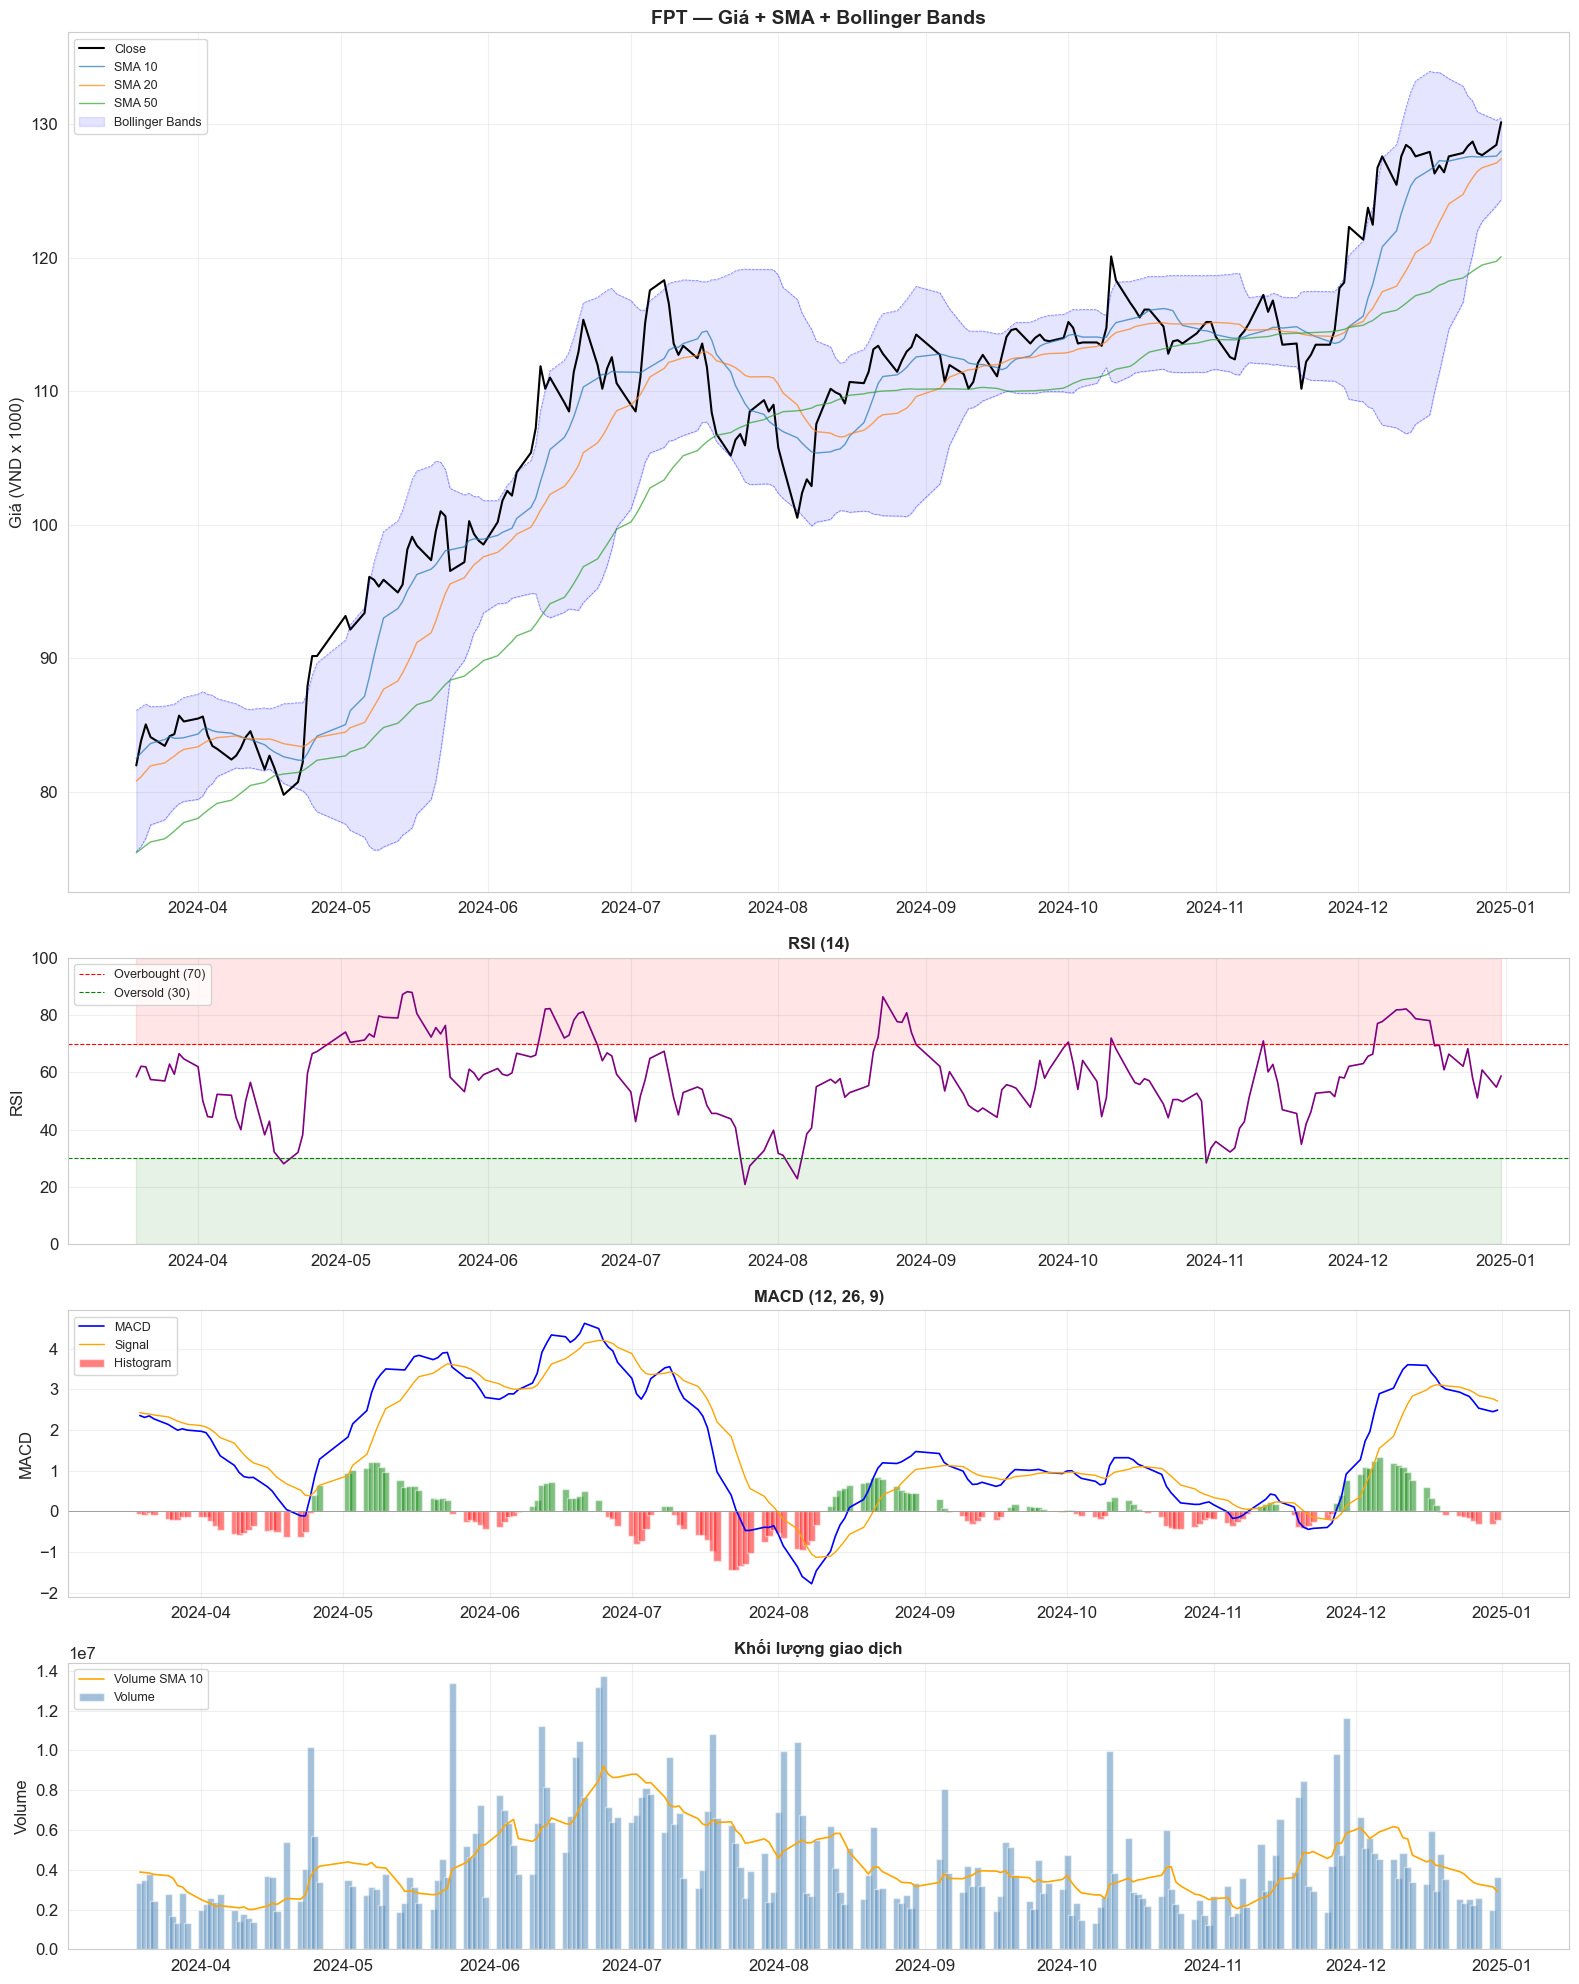

In [8]:
# Minh họa chỉ báo kỹ thuật cho FPT (dùng dữ liệu train)
sample = train_data['FPT'].copy()
sample_recent = sample.tail(200)  # 200 phiên gần nhất của train

fig, axes = plt.subplots(4, 1, figsize=(16, 20), gridspec_kw={'height_ratios': [3, 1, 1, 1]})

# --- Biểu đồ 1: Giá + SMA + Bollinger Bands ---
ax1 = axes[0]
ax1.plot(sample_recent['time'], sample_recent['close'], label='Close', linewidth=1.5, color='black')
ax1.plot(sample_recent['time'], sample_recent['SMA_10'], label='SMA 10', linewidth=1, alpha=0.7)
ax1.plot(sample_recent['time'], sample_recent['SMA_20'], label='SMA 20', linewidth=1, alpha=0.7)
ax1.plot(sample_recent['time'], sample_recent['SMA_50'], label='SMA 50', linewidth=1, alpha=0.7)
ax1.fill_between(sample_recent['time'], sample_recent['BB_upper'], sample_recent['BB_lower'], 
                  alpha=0.1, color='blue', label='Bollinger Bands')
ax1.plot(sample_recent['time'], sample_recent['BB_upper'], '--', color='blue', linewidth=0.5, alpha=0.5)
ax1.plot(sample_recent['time'], sample_recent['BB_lower'], '--', color='blue', linewidth=0.5, alpha=0.5)
ax1.set_title('FPT — Giá + SMA + Bollinger Bands', fontsize=14, fontweight='bold')
ax1.set_ylabel('Giá (VND x 1000)')
ax1.legend(loc='upper left', fontsize=9)
ax1.grid(True, alpha=0.3)

# --- Biểu đồ 2: RSI ---
ax2 = axes[1]
ax2.plot(sample_recent['time'], sample_recent['RSI_14'], color='purple', linewidth=1.2)
ax2.axhline(y=70, color='red', linestyle='--', linewidth=0.8, label='Overbought (70)')
ax2.axhline(y=30, color='green', linestyle='--', linewidth=0.8, label='Oversold (30)')
ax2.fill_between(sample_recent['time'], 70, 100, alpha=0.1, color='red')
ax2.fill_between(sample_recent['time'], 0, 30, alpha=0.1, color='green')
ax2.set_title('RSI (14)', fontsize=12, fontweight='bold')
ax2.set_ylabel('RSI')
ax2.set_ylim(0, 100)
ax2.legend(loc='upper left', fontsize=9)
ax2.grid(True, alpha=0.3)

# --- Biểu đồ 3: MACD ---
ax3 = axes[2]
ax3.plot(sample_recent['time'], sample_recent['MACD'], label='MACD', color='blue', linewidth=1.2)
ax3.plot(sample_recent['time'], sample_recent['MACD_signal'], label='Signal', color='orange', linewidth=1)
colors = ['green' if v >= 0 else 'red' for v in sample_recent['MACD_histogram']]
ax3.bar(sample_recent['time'], sample_recent['MACD_histogram'], color=colors, alpha=0.5, width=1.5, label='Histogram')
ax3.axhline(y=0, color='gray', linewidth=0.5)
ax3.set_title('MACD (12, 26, 9)', fontsize=12, fontweight='bold')
ax3.set_ylabel('MACD')
ax3.legend(loc='upper left', fontsize=9)
ax3.grid(True, alpha=0.3)

# --- Biểu đồ 4: Volume + Volume SMA ---
ax4 = axes[3]
ax4.bar(sample_recent['time'], sample_recent['volume'], color='steelblue', alpha=0.5, width=1.5, label='Volume')
ax4.plot(sample_recent['time'], sample_recent['volume_sma_10'], color='orange', linewidth=1.2, label='Volume SMA 10')
ax4.set_title('Khối lượng giao dịch', fontsize=12, fontweight='bold')
ax4.set_ylabel('Volume')
ax4.legend(loc='upper left', fontsize=9)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

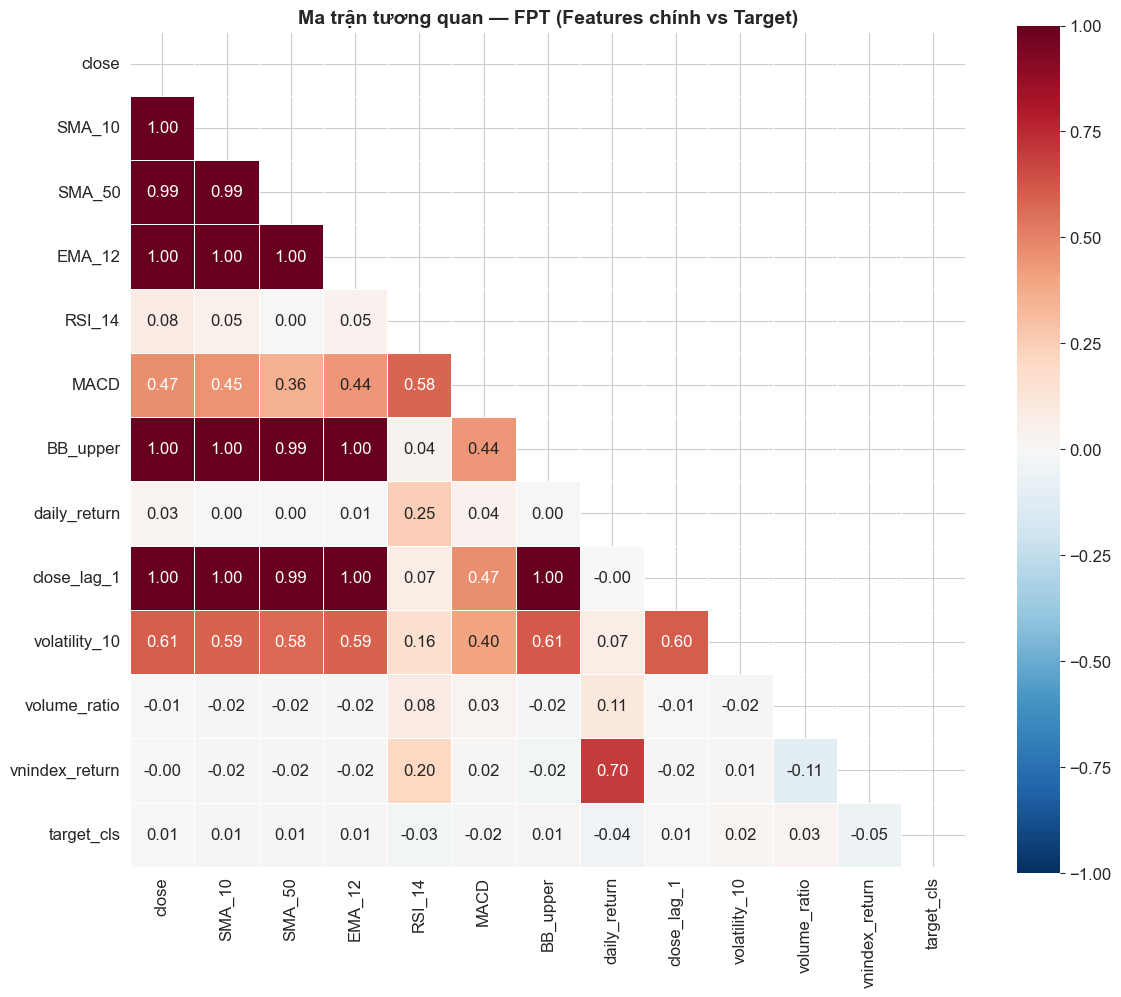


Tương quan với target_cls (Phân loại):
  vnindex_return       | -0.0539 | ██
  daily_return         | -0.0391 | █
  volume_ratio         | +0.0289 | █
  RSI_14               | -0.0280 | █
  MACD                 | -0.0215 | 
  volatility_10        | +0.0183 | 
  SMA_50               | +0.0112 | 
  SMA_10               | +0.0092 | 
  BB_upper             | +0.0091 | 
  EMA_12               | +0.0088 | 
  close_lag_1          | +0.0061 | 
  close                | +0.0055 | 


In [9]:
# Ma trận tương quan (Correlation Matrix) cho features chính
sample_df = train_data['FPT']
corr_cols = ['close', 'SMA_10', 'SMA_50', 'EMA_12', 'RSI_14', 'MACD', 
             'BB_upper', 'daily_return', 'close_lag_1', 'volatility_10', 
             'volume_ratio', 'vnindex_return', 'target_cls']
# Chỉ lấy cột tồn tại
corr_cols = [c for c in corr_cols if c in sample_df.columns]

fig, ax = plt.subplots(figsize=(12, 10))
corr_matrix = sample_df[corr_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Ma trận tương quan — FPT (Features chính vs Target)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Hiển thị tương quan với target
print("\nTương quan với target_cls (Phân loại):")
target_corr = sample_df[corr_cols].corr()['target_cls'].drop('target_cls').sort_values(key=abs, ascending=False)
for feat, corr in target_corr.items():
    bar = "█" * int(abs(corr) * 40)
    sign = "+" if corr > 0 else "-"
    print(f"  {feat:20s} | {sign}{abs(corr):.4f} | {bar}")

## Tổng kết Bước 3

### Features đã tạo (cho mỗi mã CP):

| Nhóm | Features | Số lượng |
|------|----------|---------|
| **OHLCV gốc** | open, high, low, close, volume | 5 |
| **SMA** | SMA_10, SMA_20, SMA_50 | 3 |
| **EMA** | EMA_12, EMA_26 | 2 |
| **RSI** | RSI_14 | 1 |
| **MACD** | MACD, MACD_signal, MACD_histogram | 3 |
| **Bollinger Bands** | BB_upper, BB_middle, BB_lower | 3 |
| **Daily Return** | daily_return | 1 |
| **Lag Features** | close_lag_1/3/7, return_lag_1/3/7 | 6 |
| **Volatility** | volatility_10 | 1 |
| **Volume** | volume_sma_10, volume_ratio | 2 |
| **Bổ sung** | vnindex_return, usdvnd_return | 2 |
| **Target** | target_cls (phân loại), target_reg (hồi quy) | 2 |

### Điểm nổi bật:
- ✓ Đầy đủ 5 loại chỉ báo kỹ thuật theo yêu cầu
- ✓ Lag features (1, 3, 7) + return lag
- ✓ Volatility (rolling std 10 ngày)
- ✓ Target cho cả bài toán phân loại và hồi quy
- ✓ Tích hợp VN-Index return và USD/VND return (điểm cộng)
- ✓ Volume features (SMA, ratio)
- ✓ Chia train/test đúng theo thời gian, áp dụng cho tất cả 5 mã

### Bước tiếp theo:
→ **Bước 4: Lựa Chọn Mô Hình (Model Selection)** — Huấn luyện Logistic Regression, Random Forest, XGBoost